In [41]:
import sys
import os
# import import_ipynb

MY_PATH="."
MY_LIB_PATH="../NSE/"
sys.path.append(MY_LIB_PATH)
sys.path.append(MY_PATH)

from nse_scrap import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as datetime
import Stock_Analysis as SA

In [42]:
os.getcwd()

'C:\\Users\\111075866\\Python Code\\NSE'

In [43]:
import io
def getImgData(f): 
    file = io.BytesIO()
    # r = figure.plot(kind='bar')
    # f = r.get_figure()
    f.savefig(file,format='png')
    file.seek(0)
    img_data = file.read()
    return img_data

In [44]:
import warnings
warnings.filterwarnings("ignore")

In [45]:
# stklist = ['ASPINWALL','ARE&M','COALINDIA','DRREDDY','EXIDEIND','CAMS','GAIL','HDFCBANK','ICICIBANK']
# stklist = ['ABSLAMC','ADANIPORTS','ARE&M','AMBUJACEM','ASIANPAINT','ASPINWALL','AUROPHARMA','BAJAJ-AUTO','BAJFINANCE','BALKRISIND','CAMS','CARTRADE','CASTROLIND','CEATLTD','CIPLA','COALINDIA','CROMPTON','DATAPATTNS','DRREDDY','EIDPARRY','EMBASSY-RR','EXIDEIND','GAIL','GENUSPOWER','GESHIP','GOLDBEES','GOLDETF','GULFOILLUB','HCLTECH','HDFCBANK','HDFCNIFIT','HEROMOTOCO','HGS','HIL','HINDALCO','HITECHGEAR','ICICIBANK','ICICIGOLD','ICICITECH','IDFC','IFCI','INFY','IOC','IRBINVIT','IRFC','ITC','JINDALPOLY','JINDALSAW','JSL','JUBLFOOD','KTKBANK','LGBBROSLTD','MANAPPURAM','MARUTI','MUTHOOTFIN','NATCOPHARM','NHIT-N1','NHIT-N3','NHIT-N2','PCBL','PETRONET','PGINVIT','PNBGILTS','PPL','RUBFILA','RVNL','SAIL','SBIGETS','SGBN28VIII-GB','SIL','STOVEKRAFT','TATACHEM','TATACOFFEE','TATAMOTORS','TATAMTRDVR','TATASTEEL','TCS','TECHM','TEGA','TITAGARH','TITAN','TMB','TTKPRESTIG','TVSMOTOR','VEDL','WHIRLPOOL','WIPRO','WSTCSTPAPR','ZYDUSLIFE']
stklist = ['ABSLAMC','ADANIPORTS','ARE&M','AMBUJACEM','ASIANPAINT','ASPINWALL','AUROPHARMA','BAJAJ-AUTO','BAJFINANCE','BALKRISIND','CAMS','CARTRADE','CASTROLIND','CEATLTD','CIPLA','COALINDIA','CROMPTON','DATAPATTNS','DRREDDY','EIDPARRY','EMBASSY-RR','EXIDEIND','GAIL','GENUSPOWER','GESHIP','GOLDBEES','GOLDETF','GULFOILLUB','HCLTECH','HDFCBANK','HDFCNIFIT','HEROMOTOCO','HGS','HIL','HINDALCO','HITECHGEAR','ICICIBANK','ICICIGOLD','ICICITECH','IDFC','IFCI','INFY','IOC','IRBINVIT-IV','IRFC','ITC','JINDALPOLY','JINDALSAW','JSL','JUBLFOOD','KTKBANK','LGBBROSLTD','MAGOLD','MANAPPURAM','MARUTI','MUTHOOTFIN','NATCOPHARM','NHIT-N1','NHIT-N3','NHIT-N2','PCBL','PETRONET','PGINVIT-IV','PNBGILTS','PPL','RUBFILA','RVNL','SAIL','SBIGETS','SGBN28VIII-GB','SIL-BE','STOVEKRAFT','TATACHEM','TATACOFFEE','TATAMOTORS','TATAMTRDVR','TATASTEEL','TCS','TECHM','TEGA','TITAGARH','TITAN','TMB','TTKPRESTIG','TVSMOTOR','VEDL','WHIRLPOOL','WIPRO','WSTCSTPAPR','ZYDUSLIFE']
# stklist = ['HDFCBANK','AMBUJACEM','EMBASSY-RR']
# stklist = ['EMBASSY-RR']
stklist2 = ['COSMOFIRST', 'LT','AARTIIND','SOUTHBANK','GLENMARK','PCBL','ONGC','NTPC','DMART','HINDZINC'
            ,'TATACONSUM','DABUR','HDFCAMC','ICICIPRULI','INDIANB','OFSS','GLAXO','IPCALAB','MOTILALOFS','RITES','JPPOWER','TV18BRDCST'
           , 'GNFC','METROPOLIS','PTC','MOIL','ICIL','GREAVESCOT','MAITHANALL','BALMLAWRIE','MONTECARLO','GULFPETRO','BASML']

stklist = stklist + stklist2
stklist.sort()

In [46]:
# stklist
# Get_Stock_Data3(['TV18BRDCST'], 600, MAX_THREADS=1)

In [47]:
len(stklist)

123

In [48]:
dfs = Get_Stock_Data3(stklist, 500, MAX_THREADS=10)

error - MAGOLD - 'str' object has no attribute 'tail'


In [49]:
import datetime as datetime

In [50]:
n = datetime.datetime.now().strftime("%Y-%m-%d-%H-%M-%S")
dfs.to_csv(MY_PATH+"./dump/STKS-HIS"+n+".csv")

In [51]:
sumary = None
for stk in set(dfs.symbol):
    s = dfs[ dfs["symbol"]==stk]
    s = SA.processScrip(s)
    sumary = pd.concat([sumary, s])

In [52]:
values_arr = ["close","SMA20_2_200P","SIG","52WH_P","52WL_P","52WHLP","1WHLP","1MHLP","3MHLP","6MHLP","1YHLP"]
pvt = sumary.pivot_table(values=values_arr, columns=["symbol"], index=["date"])

In [53]:
top_gainer_losers = SA.getGainerLosers(pvt)
top_gainer_losers.sort_values(by=['12md']).head(10)

date,2024-10-09 00:00:00,2024-10-08 00:00:00,2024-10-01 00:00:00,2024-09-10 00:00:00,2024-07-12 00:00:00,2024-04-16 00:00:00,2023-10-20 00:00:00,1dd,1wd,1md,3md,6md,12md
symbol,,,,,,,,,,,,,
HDFCNIFIT,43.84,43.45,43.68,43.80,40.02,34.24,318.57,0.897583,0.366300,0.091324,9.545227,28.037383,-86.238503
RITES,325.10,300.35,334.25,678.90,771.50,662.20,491.25,8.240386,-2.737472,-52.113713,-57.861309,-50.906071,-33.821883
TMB,448.60,448.50,470.90,484.80,481.50,485.75,583.35,0.022297,-4.735613,-7.466997,-6.832814,-7.647967,-23.099340
MOTILALOFS,785.70,751.80,742.80,736.85,532.50,2026.55,980.95,4.509178,5.775444,6.629572,47.549296,-61.229676,-19.904175
HGS,791.90,788.40,814.45,907.60,911.55,843.20,988.50,0.443937,-2.768740,-12.747907,-13.125994,-6.083966,-19.888720
WSTCSTPAPR,611.20,603.00,623.40,610.65,690.65,606.45,761.75,1.359867,-1.957010,0.090068,-11.503656,0.783247,-19.763702
IDFC,107.97,109.98,111.91,110.40,117.65,122.35,124.40,-1.827605,-3.520686,-2.201087,-8.227794,-11.753167,-13.207395
IRBINVIT,61.85,61.78,62.39,62.83,66.89,67.53,70.55,0.113305,-0.865523,-1.559764,-7.534759,-8.411077,-12.331680
PGINVIT,87.44,87.95,87.96,91.10,95.97,98.14,99.31,-0.579875,-0.591178,-4.017563,-8.888194,-10.902792,-11.952472


In [54]:
pvt.to_csv(MY_PATH+"./dump/STKS-HIS-processed-"+n+".csv")

In [55]:
SIGNAL_WINDOW=8
i = pvt.SMA20_2_200P.tail(SIGNAL_WINDOW)
i.loc[:, i[(i > -1.0) & (i < 1.0)].any()].T.to_csv(MY_PATH+"./dump/SIGNAL-Detail-"+n+".csv")
ip = i.loc[:, i[(i > -1.0) & (i < 1.0)].any()].T
ip
# temp2 = pts.loc[:,pts[(pts > 0.75*1e6) & (pts < 0.3*1e7)].any() ]

date,2024-09-27,2024-09-30,2024-10-01,2024-10-03,2024-10-04,2024-10-07,2024-10-08,2024-10-09
symbol,,,,,,,,
DATAPATTNS,1.427417,0.536347,-0.349406,-1.341881,-2.289397,-3.290211,-4.027643,-4.748951
HGS,-0.158476,-0.464511,-0.881130,-1.302782,-1.757154,-2.264568,-2.626809,-3.167562
INDIANB,1.094254,0.699165,0.392961,0.120690,-0.214525,-0.322161,-0.349301,-0.340490
IRFC,4.796725,3.947061,2.979460,1.988767,1.124589,0.165938,-0.532188,-1.207645
KTKBANK,-0.942770,-0.948292,-0.672269,-0.396958,-0.255276,-0.149335,-0.151550,-0.037495
MAITHANALL,-0.571719,-0.508341,-0.263938,-0.161940,-0.064806,-0.101358,-0.007594,-0.052690
MOIL,0.264212,0.451440,0.577359,0.488871,0.261471,-0.263015,-0.513264,-0.933750
TATACHEM,-1.224378,-1.225623,-1.170460,-0.987003,-0.820850,-0.744685,-0.611153,-0.445879
TATAMOTORS,5.338604,4.583613,3.822912,2.906648,2.074360,1.339831,0.623645,0.013188


In [56]:
s = pvt.SIG.tail(SIGNAL_WINDOW)
s.loc[:, s[(s == 1) | (s==-1) ].any()].T.to_csv(MY_PATH+"./dump/SIGNAL-"+n+".csv")
sp  = s.loc[:, s[(s == 1) | (s==-1) ].any()].T
sp

date,2024-09-27,2024-09-30,2024-10-01,2024-10-03,2024-10-04,2024-10-07,2024-10-08,2024-10-09
symbol,,,,,,,,
DATAPATTNS,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
HGS,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
INDIANB,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
IRFC,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
MOIL,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0
TATASTEEL,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
TV18BRDCST,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0


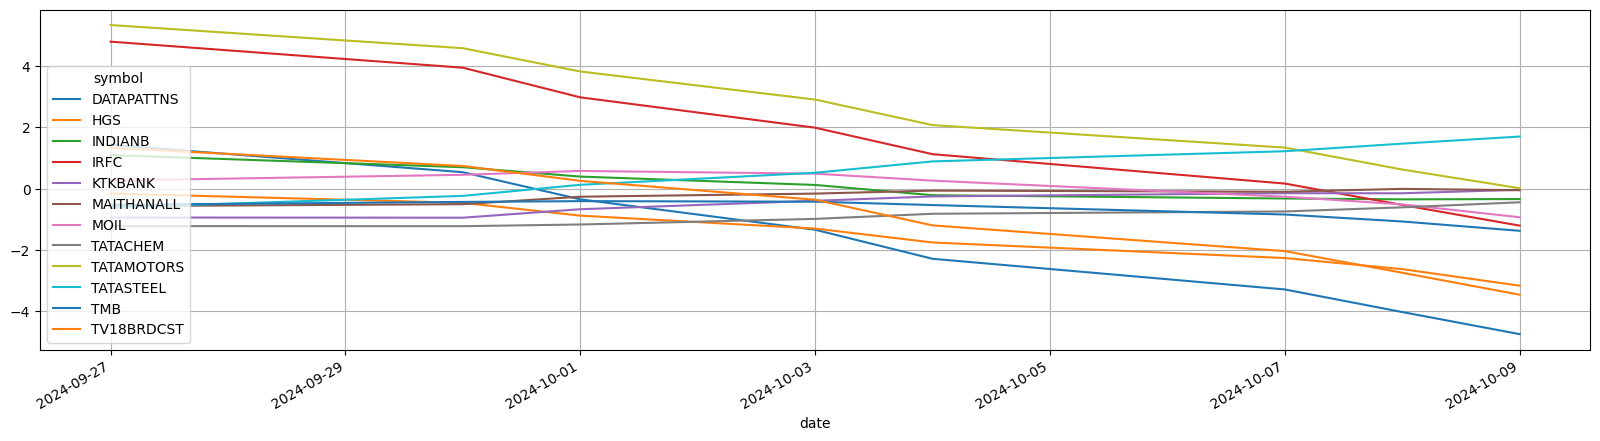

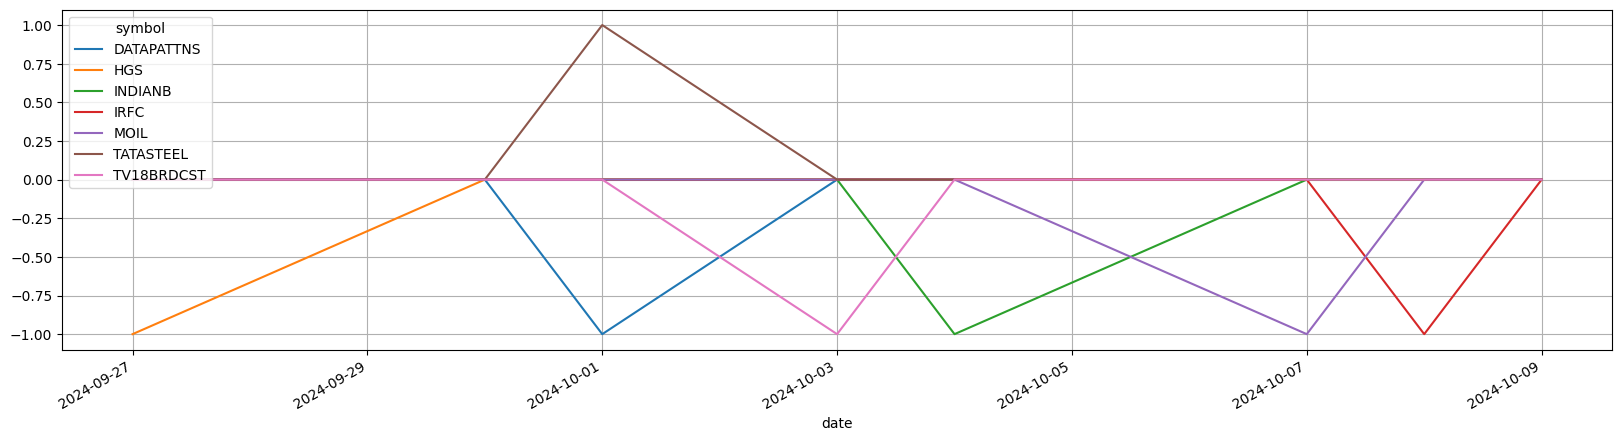

In [57]:
if (ip.shape[0] > 0 ):
    ipfig = ip.T.plot(figsize=(20,5), grid=True).get_figure()
if (sp.shape[0] > 0 ):
    spfig = sp.T.plot(figsize=(20,5), grid=True).get_figure()

In [58]:
i52whp = pvt["52WH_P"].tail(5)
i52wlp = pvt["52WL_P"].tail(5)
i52whlp = pvt["52WHLP"].tail(5)

In [59]:
# stocks staying close to 52WL. 
g52wl = i52wlp.loc[:, i52wlp[(i52wlp < 20) ].any()].T
g52wh = i52whp.loc[:, i52whp[(i52whp > 40.0) ].any()].T
g52wl

date,2024-10-03,2024-10-04,2024-10-07,2024-10-08,2024-10-09
symbol,,,,,
ASIANPAINT,17.946893,15.070597,14.686716,15.652972,15.308415
BAJFINANCE,20.137205,16.541420,17.479557,16.147096,17.981350
DABUR,18.601799,17.017580,16.394113,15.975061,15.504906
GNFC,14.773401,9.402795,7.022448,8.403219,9.690809
HDFCBANK,23.354479,21.568699,18.646181,21.084669,19.771919
HGS,11.317474,10.211464,6.441291,9.682805,10.169727
IDFC,4.105263,4.507177,5.799043,5.244019,3.320574
IRBINVIT,1.016393,0.803279,0.721311,1.278689,1.393443
JINDALSAW,115.340131,121.016588,114.609648,127.560493,12.387764


In [60]:
# i52whp.T
g52wh

date,2024-10-03,2024-10-04,2024-10-07,2024-10-08,2024-10-09
symbol,,,,,
HDFCNIFIT,88.937323,88.921847,88.859943,88.792881,88.692288
JINDALSAW,6.895644,4.441374,7.211475,1.612054,51.408080
MOTILALOFS,73.124603,72.844554,73.716441,71.927859,70.662037
RITES,61.153823,61.589685,64.180640,63.635813,60.639264
SOUTHBANK,39.377335,40.149440,42.191781,40.572852,40.373599
TITAGARH,40.235641,40.949946,43.506682,41.427028,42.241493
TV18BRDCST,36.695779,38.369723,40.917031,40.043668,38.966521


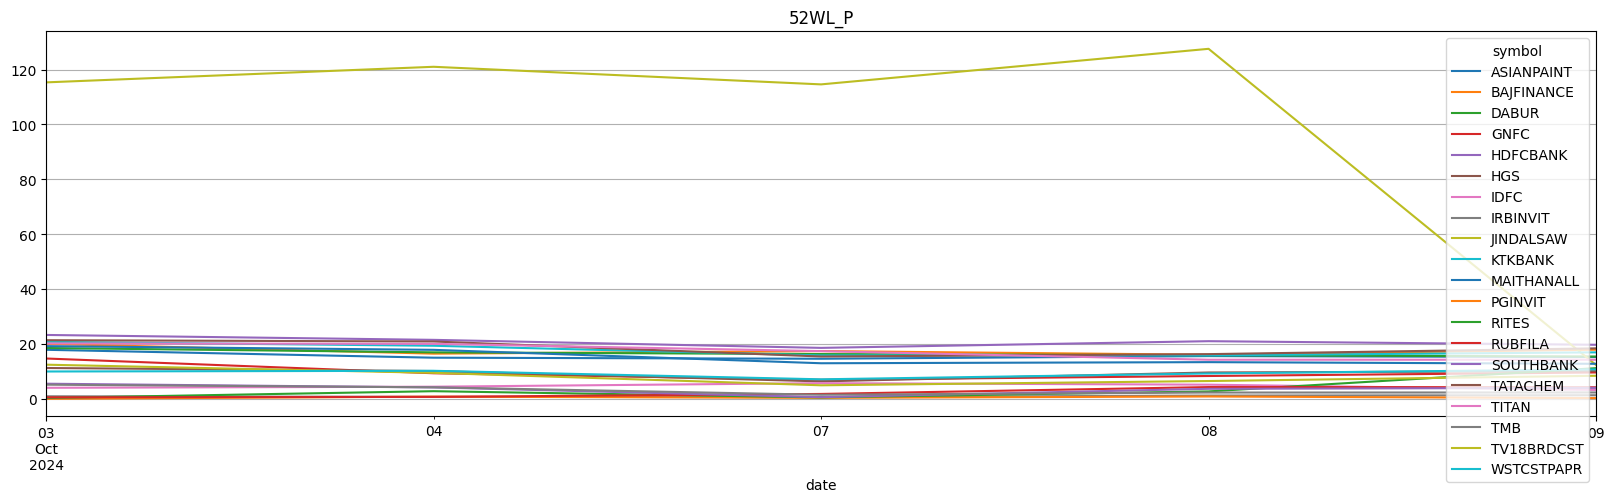

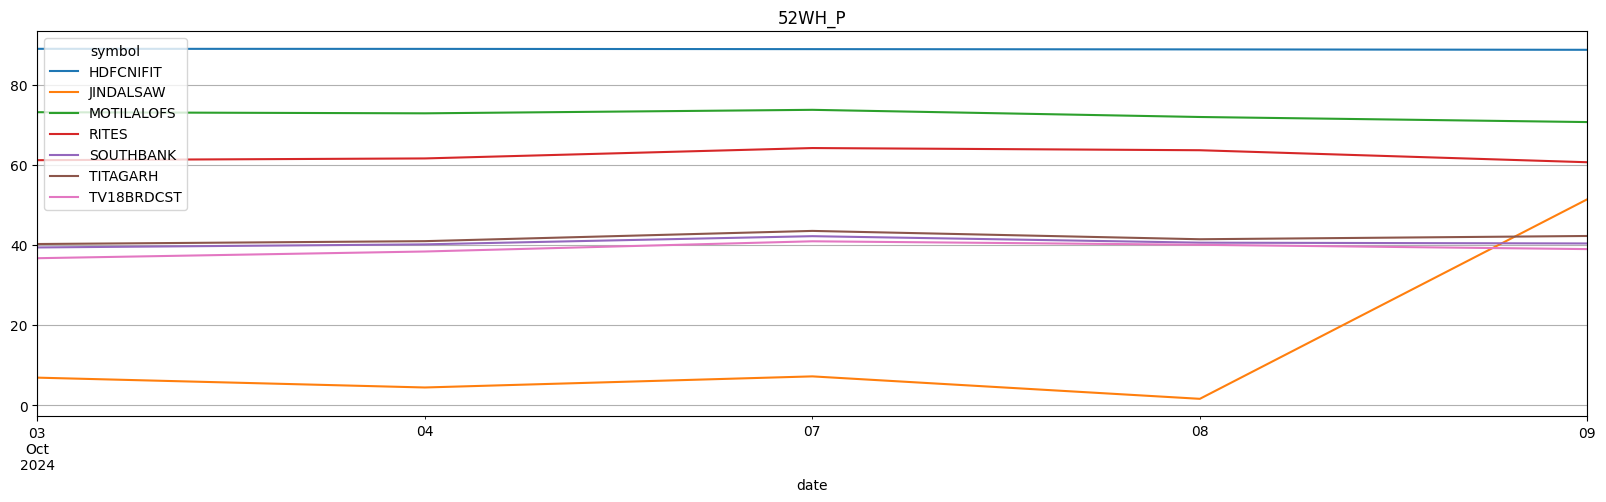

In [61]:
if (g52wl.shape[0] > 0 ):
    g52wl.T.plot(figsize=(20,5), grid=True,title='52WL_P')
if (g52wh.shape[0] > 0 ):
    g52wh.T.plot(figsize=(20,5), grid=True,title='52WH_P')    

In [62]:
# stocks fell a lot from 52WH close to 52WL. 
i52whp.loc[:, i52whp[(i52whp > 30.0) ].any()].T

date,2024-10-03,2024-10-04,2024-10-07,2024-10-08,2024-10-09
symbol,,,,,
AARTIIND,26.857329,28.352291,30.978226,30.081248,31.088723
DATAPATTNS,37.637483,36.244870,38.764706,34.961696,34.389877
HDFCNIFIT,88.937323,88.921847,88.859943,88.792881,88.692288
HINDZINC,35.260617,35.960134,38.665346,36.758698,37.421072
IFCI,32.188184,32.713348,33.260394,30.711160,30.393873
IRFC,33.799127,33.593886,36.965066,33.703057,32.978166
JINDALSAW,6.895644,4.441374,7.211475,1.612054,51.408080
MOIL,33.511905,34.353741,38.486395,36.224490,35.714286
MOTILALOFS,73.124603,72.844554,73.716441,71.927859,70.662037


In [63]:
ULIM_52WH = 90
LLIM_52WH = 25

i52whlpl_all = i52whlp.tail(1).T
i52whlpl_low = i52whlp.tail(1).loc[:, i52whlp[(i52whlp<LLIM_52WH)].any()].T
i52whlpl_high = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>ULIM_52WH)].any()].T
col = i52whlpl_all.columns.values[0]

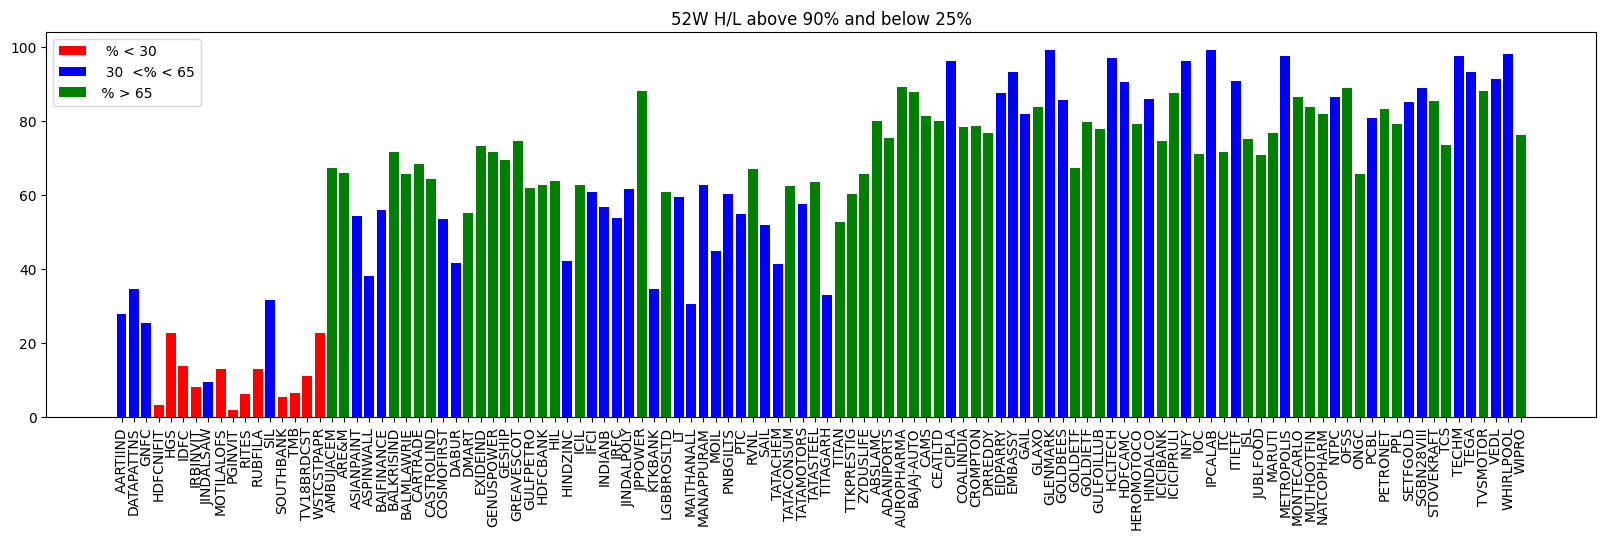

In [64]:
# i52whlpl.plot(kind='bar', figsize=(20,5), grid=True)
plt.figure(figsize=(20,5))
plt.xticks(rotation=90)

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp<=30)].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='red', label="  % < 30")

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>30) & (i52whlp<=65) ].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='blue', label="  30  <% < 65")

i52whlpl_tmp = i52whlp.tail(1).loc[:, i52whlp[(i52whlp>65) ].any()].T
plt.bar(i52whlpl_tmp.index, i52whlpl_tmp[col], color='green',label=" % > 65")

plt.bar(i52whlpl_high.index, i52whlpl_high[col], color='blue')
plt.title("52W H/L above {}% and below {}%".format(ULIM_52WH, LLIM_52WH))
plt.legend()
fig52whlclr = plt
fig52whlclr = getImgData(fig52whlclr)
plt.show()


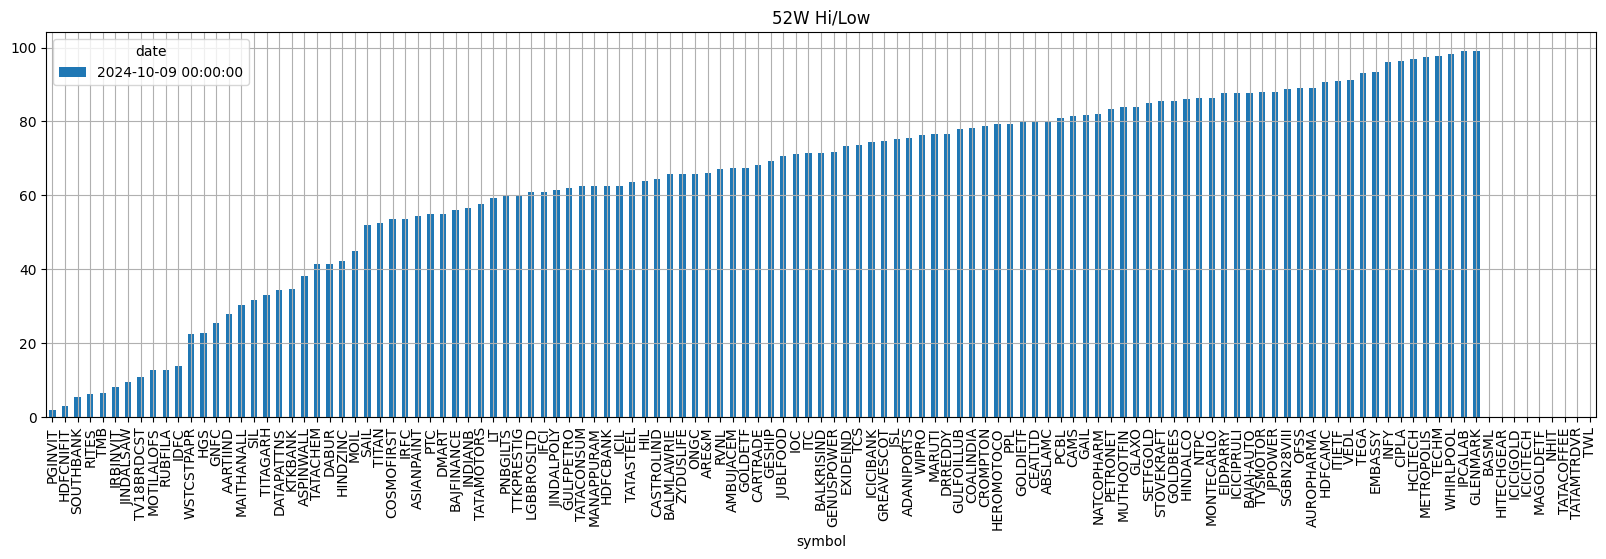

In [65]:
fig52whl = i52whlpl_all.sort_values(by=[col]).plot(kind='bar', figsize=(20,5), grid=True, title='52W Hi/Low').get_figure()

In [66]:
i52whlpl_allcsv = pd.DataFrame(i52whlpl_all[col])

In [67]:
i52whlpl_allcsv.sort_values(by=[col]).to_csv(MY_PATH+"./dump/STKS-52WHLP-"+n+".csv")

In [68]:
i52whlpl_allcsv.sort_values(by=[col])

,2024-10-09
symbol,
PGINVIT,1.837582
HDFCNIFIT,3.168032
SOUTHBANK,5.481050
RITES,6.163934
TMB,6.514356
...,...
MAGOLDETF,NaN
NHIT,NaN
TATACOFFEE,NaN


In [69]:
t1WHLP, t1MHLP, t3MHLP, t6MHLP, t1YHLP = SA.getProcessedGainerLoser(pvt)

In [70]:
t1mhl, t3mhl, t6mhl, t1yhl = SA.getProcessedByMilestone(pvt)
# t1mhl.size

In [71]:
style_text = """
<meta name="viewport" content="width=device-width, initial-scale=1">
<style>
* {
  box-sizing: border-box;
}

/* Create two equal columns that floats next to each other */
.col {
  float: left;
  width: 50%;
}

/* Clear floats after the columns */
.row:after {
  width: 50%;
}
</style>

"""

In [72]:
# email
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.image import MIMEImage
import os
from base64 import b64encode

me  = 'peri47.study@gmail.com'
recipient = 'peri47.study@gmail.com'
subject = 'Signals for {}'.format('NSE')

email_server_host = 'smtp.gmail.com'
port = 587
email_username = 'peri47.study@gmail.com'
email_password = 'zjxs btty xvqt gpuj'


msg = MIMEMultipart('alternative')
msg['From'] = me
msg['To'] = recipient
msg['Subject'] = subject
img_format = 'png'


msg.add_header('Content-Type','text/html')
section1 = """\
<html>
    <head> 
    {style_text}
    </head>
    <body>
            <H1>Stocks in Golden X - Signals: </H1>
            {signal_goldenx}
            <H1>Stocks nearing Golden X : </H1>
            {nearing_goldenx}
        <div class="row">
            <div class="col">
                <H1> %  From 52W H/L - Top 10: (Near Low)</H1>
                {hl52w_top10}
            </div>
            <div class="col">
                <H1>% From 52W H/L - Bottom10: (Near High)</H1>
                {hl52w_last10}
            </div>
        </div>
        <section>
            <div class="row">        
                <div class="col">
                    <H1> 1 weekLow </H1>
                    {l1w}
                </div>

                <div class="col">
                    <H1> 1 week Hi </H1>
                    {h1w}
                </div>
            </div>
        </section>
        <section>
            <div class="row">        
                <div class="row">        
                    <H1> 3 month low </H1>
                    {l3m}
                </div>

                <div class="col">
                    <H1> 3 month Hi </H1>
                    {h3m}
                </div>
            </div>
        </section>
        <section>
            <H1> Top Gainers / Losers  </H1>
                    <H1> 1 Week losers </H1>
                    {l1wl}
                    <H1> 1 Week gainers </H1>
                    {l1wh}
            <H1> 1 Month losers </H1>
            {l1ml}
            <H1> 1 Month gainers </H1>
            {l1mh}
            <H1> 3 Month losers </H1>
            {l3ml}
            <H1> 3 Month gainers </H1>
            {l6mh}
            <H1> 6 Month losers </H1>
            {l6ml}
            <H1> 6 Month gainers </H1>
            {l3mh}
        </section>
        
    </body>
</html>
""".format(nearing_goldenx=ip.to_html(),
           signal_goldenx=sp.to_html(),
           hl52w_top10 = i52whlpl_all.sort_values(by=[col]).head(10).to_html(), 
           hl52w_last10 = i52whlpl_all.sort_values(by=[col]).tail(10).to_html(),
           h1w = t1mhl.tail(10).to_html() , l1w = t1mhl.head(10).to_html() , h3m = t3mhl.tail(10).to_html(),
           l3m= t3mhl.head(10).to_html(),
           l1wl = top_gainer_losers.sort_values(by=['1wd']).head(10).to_html(),
           l1wh = top_gainer_losers.sort_values(by=['1wd']).tail(10).to_html(),
           l1ml = top_gainer_losers.sort_values(by=['1md']).head(10).to_html(),
           l1mh = top_gainer_losers.sort_values(by=['1md']).tail(10).to_html(),
           l3ml = top_gainer_losers.sort_values(by=['3md']).head(10).to_html(),
           l3mh = top_gainer_losers.sort_values(by=['3md']).tail(10).to_html(),
           l6ml = top_gainer_losers.sort_values(by=['6md']).head(10).to_html(),
           l6mh = top_gainer_losers.sort_values(by=['6md']).tail(10).to_html(),
           style_text = style_text,
           date=col )
email_body = section1
# msg.a

msg.attach(MIMEText(section1, 'html'))
# msgimg = 
msg.attach(MIMEImage(getImgData(fig52whl)))
msg.attach(MIMEImage(fig52whlclr))

try:
    ipfig
except: 
    #ignore
    print('')
else:
    msg.attach(MIMEImage(getImgData(ipfig)))

try:
    spfig
except: 
    #ignore
    print('')
else:
    msg.attach(MIMEImage(getImgData(spfig)))

# f = open("./test.html", "w")
# f.write(section1)
# f.close()

In [73]:
server = smtplib.SMTP(email_server_host, port)
server.ehlo()
server.starttls()
server.login(email_username, email_password)
server.sendmail(me, recipient, msg.as_string())
server.close()
